In [9]:
# Build the imagined-runs dataset. Expect ~(4770, 64, 321) and near-even classes.
X, y, subjects, runs = build_dataset(ALL_SUBJECTS, IMAGINED_RUNS)
X = X.astype(np.float32)
print(X.shape, np.bincount(y), len(np.unique(subjects)))

(4755, 64, 321) [2399 2356] 106


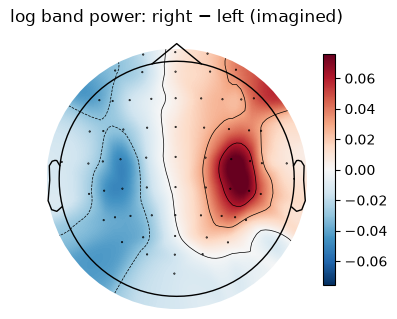

In [10]:
# Physiological check: mean log band power per channel, right minus left,
# computed within each subject first so between-person amplitude differences
# don't swamp the within-person effect.
info = epoch_run(1, 4).info
log_power = np.log((X ** 2).mean(axis=2))

subject_list = np.unique(subjects)
contrasts = np.stack([
    log_power[(subjects == s) & (y == 1)].mean(axis=0)
    - log_power[(subjects == s) & (y == 0)].mean(axis=0)
    for s in subject_list
])
assert np.isfinite(contrasts).all()

fig, ax = plt.subplots(figsize=(4.2, 4))
im, _ = mne.viz.plot_topomap(contrasts.mean(axis=0), info, axes=ax, contours=4, show=False)
fig.colorbar(im, ax=ax, shrink=0.75)
ax.set_title("log band power: right − left (imagined)")
fig.savefig(RESULTS_DIR / "erd_topomap_imagined.png", dpi=150, bbox_inches="tight")

In [11]:
# Repeat on executed runs. This is the positive control — the effect is much
# stronger here, so a flat map on executed means a pipeline bug, not weak imagery.
X_ex, y_ex, subjects_ex, _ = build_dataset(ALL_SUBJECTS, EXECUTED_RUNS)
# ... same contrast + topomap, saved as erd_topomap_executed.png

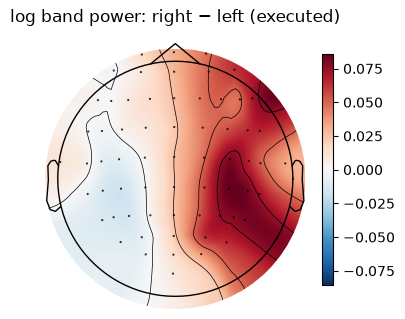

In [12]:
# Positive control: same contrast on executed runs, where the effect is much stronger.
log_power_ex = np.log((X_ex ** 2).mean(axis=2))

contrasts_ex = np.stack([
    log_power_ex[(subjects_ex == s) & (y_ex == 1)].mean(axis=0)
    - log_power_ex[(subjects_ex == s) & (y_ex == 0)].mean(axis=0)
    for s in np.unique(subjects_ex)
])
assert np.isfinite(contrasts_ex).all()

fig, ax = plt.subplots(figsize=(4.2, 4))
im, _ = mne.viz.plot_topomap(contrasts_ex.mean(axis=0), info, axes=ax, contours=4, show=False)
fig.colorbar(im, ax=ax, shrink=0.75)
ax.set_title("log band power: right − left (executed)")
fig.savefig(RESULTS_DIR / "erd_topomap_executed.png", dpi=150, bbox_inches="tight")

In [13]:
# Per-subject effect size, which the group-average map understates.
c3, c4 = info.ch_names.index("C3"), info.ch_names.index("C4")
li_im = contrasts[:, c4] - contrasts[:, c3]
li_ex = contrasts_ex[:, c4] - contrasts_ex[:, c3]

for name, li in [("imagined", li_im), ("executed", li_ex)]:
    print(f"{name}: median {np.median(li):.3f}, frac positive {(li > 0).mean():.2f}")

pd.DataFrame({
    "subject": np.unique(subjects), "li_imagined": li_im, "li_executed": li_ex,
}).to_csv(RESULTS_DIR / "lateralization_index.csv", index=False)

imagined: median 0.068, frac positive 0.81
executed: median 0.070, frac positive 0.82


<h1>Verification cells

In [14]:
# 1. Confirm the two datasets are genuinely different data, not an aliasing accident.
print("same object:", X is X_ex)
print("identical values:", np.array_equal(X, X_ex))
print("shapes:", X.shape, X_ex.shape)

same object: False
identical values: False
shapes: (4755, 64, 321) (4755, 64, 321)


In [15]:
# 2. Confirm each dataset drew from the runs it was supposed to.
_, _, _, runs_ex = build_dataset(ALL_SUBJECTS, EXECUTED_RUNS)
print("imagined runs:", sorted(np.unique(runs)))
print("executed runs:", sorted(np.unique(runs_ex)))

imagined runs: [np.int64(4), np.int64(8), np.int64(12)]
executed runs: [np.int64(3), np.int64(7), np.int64(11)]


In [16]:
# 3. The CSV pairs li_im and li_ex by position, which is only valid if both
#    datasets contain the same subjects in the same order.
assert np.array_equal(np.unique(subjects), np.unique(subjects_ex))

In [17]:
# 4. The check that distinguishes "no paradigm difference" from "same direction,
#    better signal-to-noise": effect size, not just mean effect.
def lateralization_d(X_, y_, subjects_):
    """Per-subject Cohen's d of the C4-C3 lateralization across trials."""
    lat = np.log((X_[:, c4] ** 2).mean(axis=1)) - np.log((X_[:, c3] ** 2).mean(axis=1))
    out = []
    for s in np.unique(subjects_):
        m = subjects_ == s
        r, l = lat[m & (y_ == 1)], lat[m & (y_ == 0)]
        pooled = np.sqrt((r.var(ddof=1) + l.var(ddof=1)) / 2)
        out.append((r.mean() - l.mean()) / pooled)
    return np.array(out)

d_im = lateralization_d(X, y, subjects)
d_ex = lateralization_d(X_ex, y_ex, subjects_ex)
print(f"imagined d: {np.median(d_im):.3f}   executed d: {np.median(d_ex):.3f}")

imagined d: 0.305   executed d: 0.371
